# 🔆 Solar Power Plant Analysis - Jupyter Notebook Version

Dashboard analisis lengkap untuk data Solar Power Plant dengan fitur:
- **Data Loading & Cleaning**: Membaca dan membersihkan data Excel
- **Overview & Statistik**: Ringkasan kinerja dan pola produksi
- **Analisis Temporal**: Pola harian, mingguan, dan musiman
- **Korelasi & Hubungan**: Analisis hubungan antar variabel
- **Forecasting**: Prediksi produksi menggunakan multiple models
- **Business Insights**: Wawasan bisnis dan rekomendasi

*Versi ringkas dari Streamlit dashboard untuk eksplorasi data interaktif*

In [ ]:
# Import library yang dibutuhkan
import glob
import math
import os
import re
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine learning libraries
try:
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    from sklearn.linear_model import LinearRegression, Ridge
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.preprocessing import StandardScaler
    SKLEARN_OK = True
    print("✓ Scikit-learn loaded successfully")
except ImportError:
    SKLEARN_OK = False
    print("⚠️ Scikit-learn not available")

# Plotly untuk visualisasi interaktif (opsional)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_OK = True
    print("✓ Plotly loaded successfully")
except ImportError:
    PLOTLY_OK = False
    print("⚠️ Plotly not available - using matplotlib")

# Konfigurasi
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

# Setup untuk tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("🔧 Setup completed!")

In [ ]:
## 📊 Data Loading & Helper Functions

# Mapping kolom standar
STANDARD_COLS = {
    "date_hour": ["Date - Hour (NMT)", "Date – Hour (NMT)", "Date—Hour (NMT)", 
                  "Date Hour (NMT)", "Date_Hour_NMT", "Date/Hour", "Datetime", "DateTime"],
    "wind_speed": ["Wind Speed","Wind_Speed"],
    "sunshine": ["Sunshine"],
    "air_pressure": ["Air Pressure","Air_Pressure"],
    "radiation": ["Radiation"],
    "air_temperature": ["Air Temperature","Air_Temperature"],
    "relative_air_humidity": ["Relative Air Humidity","Relative_Air_Humidity"],
    "system_production": ["System Production","System_Production","Production",
                         "SystemProduction","Actual","y","Y"]
}

def find_column(df, col_key):
    """Cari kolom berdasarkan nama standar"""
    for col in STANDARD_COLS[col_key]:
        if col in df.columns:
            return col
    return None

def clean_numeric(series):
    """Bersihkan data numerik dengan format Eropa/internasional"""
    if series.dtype == 'O':
        s = series.astype(str)
        s = s.str.replace(r"[^\d,\.\-]+", "", regex=True)
        
        # Handle format Eropa (koma sebagai desimal)
        has_both = s.str.contains(",", na=False) & s.str.contains(r"\.", na=False, regex=True)
        s = np.where(
            has_both,
            s.str.replace(r"\.", "", regex=True).str.replace(",", ".", regex=False),
            s.str.replace(",", ".", regex=False)
        )
        series = pd.Series(s)
    
    return pd.to_numeric(series, errors="coerce")

def parse_datetime(s):
    """Parse datetime dengan berbagai format"""
    def parse_one(x):
        if pd.isna(x): 
            return pd.NaT
        
        if isinstance(x, pd.Timestamp):
            return x
        
        x_str = str(x).strip()
        formats = [
            "%d/%m/%Y %H:%M",
            "%m/%d/%Y %H:%M", 
            "%d.%m.%Y %H:%M",
            "%Y-%m-%d %H:%M:%S",
            "%Y-%m-%d %H:%M",
            "%d-%m-%Y %H:%M"
        ]
        
        for fmt in formats:
            try:
                return pd.to_datetime(x_str, format=fmt)
            except:
                continue
        
        try:
            return pd.to_datetime(x_str, dayfirst=True)
        except:
            return pd.to_datetime(x_str, errors="coerce")
    
    return s.apply(parse_one)

print("✓ Helper functions defined")

In [20]:
# Import libraries
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
print("📚 Libraries loaded")

📚 Libraries loaded


## 1. Data Loading

In [21]:
def _to_float(val):
    """Convert European format to float"""
    if pd.isna(val) or val == '':
        return np.nan
    if isinstance(val, (int, float)):
        return float(val)
    if isinstance(val, str):
        val = val.strip().replace('.', '').replace(',', '.')
        try:
            return float(val)
        except:
            return np.nan
    return np.nan

def load_data():
    """Load dan preprocess data"""
    # Cari file new.xlsx
    files = [f for f in os.listdir('.') if 'new' in f and f.endswith('.xlsx')]
    if not files:
        print("❌ File new.xlsx tidak ditemukan")
        return None
    
    file = files[0]
    print(f"📁 Loading: {file}")
    
    # Read Excel
    df = pd.read_excel(file)
    print(f"📊 Shape: {df.shape}")
    
    # Parse datetime dan numerik
    for col in df.columns:
        if 'date' in col.lower() or 'time' in col.lower():
            df[col] = pd.to_datetime(df[col], errors='coerce')
        elif df[col].dtype == 'object':
            df[col] = df[col].apply(_to_float)
    
    return df

# Load data
data = load_data()

📁 Loading: Solar Power Plant Data XLSX new.xlsx
📊 Shape: (744, 17)
📊 Shape: (744, 17)


In [22]:
# Load data using our function
data = load_data()

if data is not None:
    print(f"✅ Data loaded successfully!")
    print(f"📊 Columns: {list(data.columns)}")
else:
    print("❌ Failed to load data - check if new.xlsx file exists")

📁 Loading: Solar Power Plant Data XLSX new.xlsx
📊 Shape: (744, 17)
✅ Data loaded successfully!
📊 Columns: ['Date Hour (NMT)', 'Wind Speed', 'Sunshine', 'Air Pressure', 'Radiation', 'Air Temperature', 'Relative Air Humidity', 'System Production', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16']


In [23]:
def add_features(df, datetime_col, target_col):
    """Add all necessary features"""
    print("⚙️ Adding features...")
    
    # Time features
    df['hour'] = df[datetime_col].dt.hour
    df['month'] = df[datetime_col].dt.month
    df['weekday'] = df[datetime_col].dt.weekday
    
    # Circular encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Solar features
    df['is_daylight'] = ((df['hour'] >= 6) & (df['hour'] <= 18)).astype(int)
    df['is_weekend'] = (df['weekday'] >= 5).astype(int)
    
    # Lag features (only if target column exists)
    if target_col in df.columns:
        for lag in [1, 3, 6, 24]:
            df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
        
        # Rolling features
        for window in [6, 24]:
            df[f'{target_col}_rolling_{window}'] = df[target_col].rolling(window).mean()
    
    print(f"✅ Features added. Shape: {df.shape}")
    return df

# Identifikasi datetime dan target columns
datetime_col = [col for col in data.columns if 'date' in col.lower() or 'time' in col.lower()][0]
# Find power column - it might be System Production
power_cols = [col for col in data.columns if 'power' in col.lower() or 'production' in col.lower() or 'system' in col.lower()]
target_col = power_cols[0] if power_cols else 'System Production'

print(f"📅 Datetime column: {datetime_col}")
print(f"🎯 Target column: {target_col}")

# Add features
data = add_features(data, datetime_col, target_col)

📅 Datetime column: Date Hour (NMT)
🎯 Target column: System Production
⚙️ Adding features...


✅ Features added. Shape: (744, 30)


📊 Dataset Info:
Shape: (744, 30)
Date range: 2017-01-01 00:00:00 to 2017-12-01 23:00:00
Target stats: min=0.00, max=16063333.00


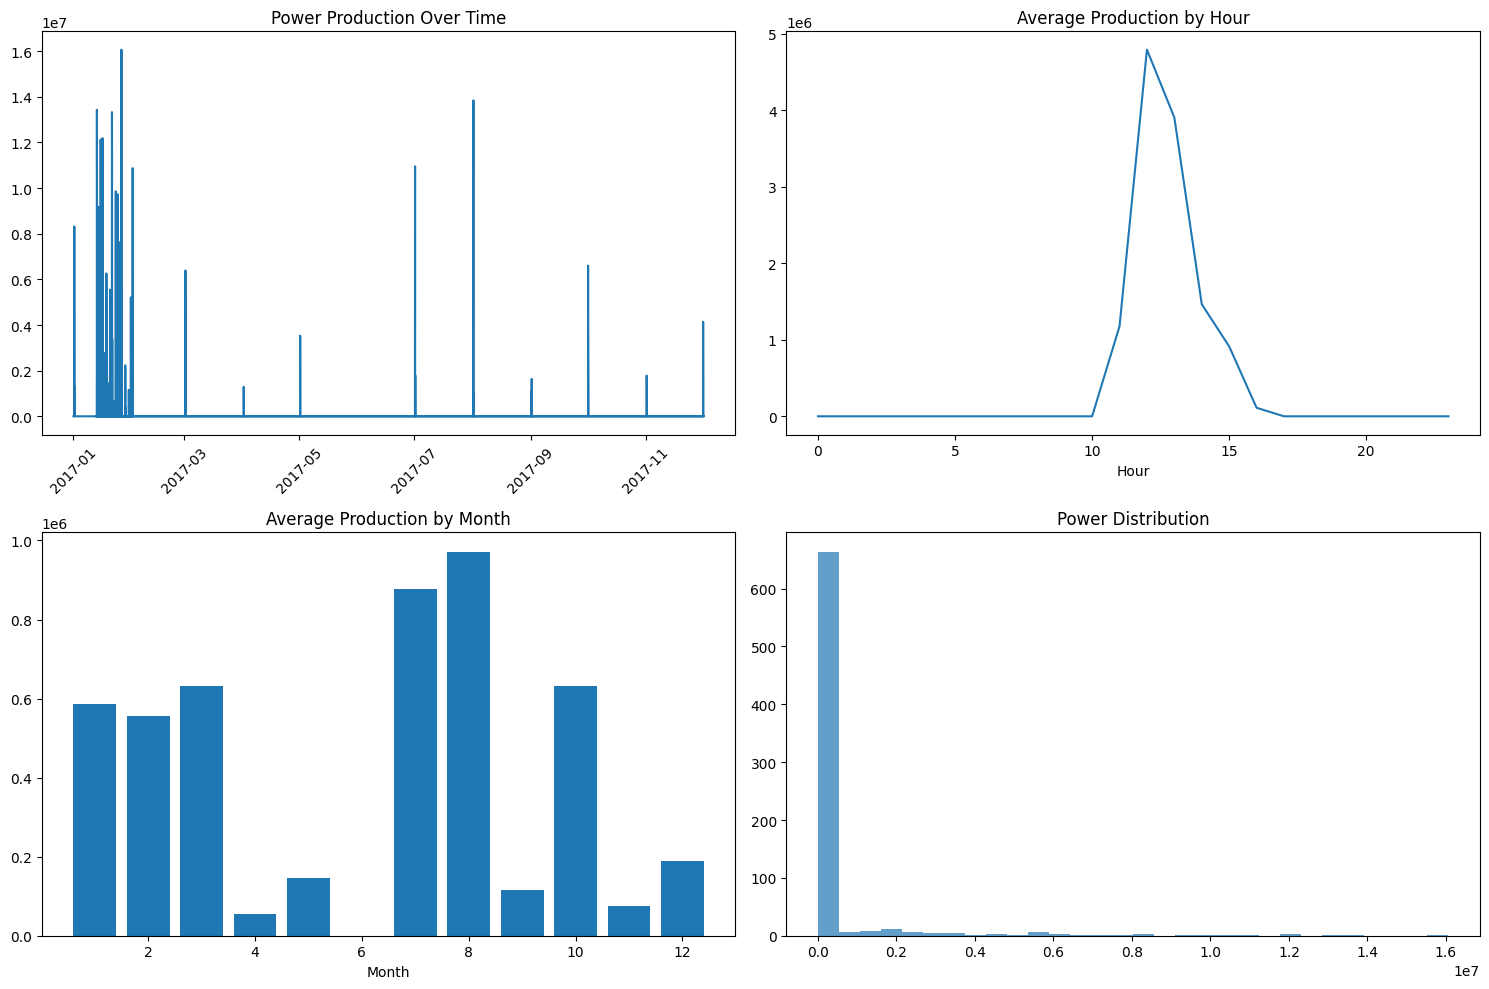

In [24]:
# Quick EDA
print("📊 Dataset Info:")
print(f"Shape: {data.shape}")
print(f"Date range: {data[datetime_col].min()} to {data[datetime_col].max()}")
print(f"Target stats: min={data[target_col].min():.2f}, max={data[target_col].max():.2f}")

# Basic plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time series plot
axes[0,0].plot(data[datetime_col], data[target_col])
axes[0,0].set_title('Power Production Over Time')
axes[0,0].tick_params(axis='x', rotation=45)

# Hourly pattern
hourly = data.groupby('hour')[target_col].mean()
axes[0,1].plot(hourly.index, hourly.values)
axes[0,1].set_title('Average Production by Hour')
axes[0,1].set_xlabel('Hour')

# Monthly pattern
monthly = data.groupby('month')[target_col].mean()
axes[1,0].bar(monthly.index, monthly.values)
axes[1,0].set_title('Average Production by Month')
axes[1,0].set_xlabel('Month')

# Distribution
axes[1,1].hist(data[target_col].dropna(), bins=30, alpha=0.7)
axes[1,1].set_title('Power Distribution')

plt.tight_layout()
plt.show()

## 3. Model Training

In [25]:
# Debug: Check for NaN values
print("🔍 Checking for NaN values...")
print(f"Data columns with NaN: {data.isna().sum().sum()}")

# Prepare features (only use numeric features to avoid issues)
feature_cols = [col for col in data.columns if col not in [datetime_col, target_col] and data[col].dtype in ['float64', 'int64']]
model_data = data[[datetime_col, target_col] + feature_cols].copy()

print(f"📊 Using {len(feature_cols)} features")
print(f"Feature columns: {feature_cols[:5]}...")  # Show first 5

# Simple approach: drop rows with any NaN
model_data = model_data.dropna()

print(f"📊 Clean data shape: {model_data.shape}")

if len(model_data) < 50:
    print("❌ Too little data after cleaning. Using simple features only.")
    # Use only basic features
    basic_features = ['hour', 'month', 'weekday', 'is_daylight', 'is_weekend']
    available_basic = [col for col in basic_features if col in data.columns]
    model_data = data[[datetime_col, target_col] + available_basic].dropna()
    feature_cols = available_basic

print(f"📊 Final data shape: {model_data.shape}")

# Train/test split (90%/10%)
train_size = int(0.9 * len(model_data))
X_train = model_data[feature_cols][:train_size]
y_train = model_data[target_col][:train_size]
X_test = model_data[feature_cols][train_size:]
y_test = model_data[target_col][train_size:]

print(f"📈 Train: {len(X_train)} records")
print(f"📉 Test: {len(X_test)} records")

# Model 1: Simple hourly average baseline
hourly_avg = model_data.groupby('hour')[target_col].mean()[:train_size]
baseline_pred = []
for hour in X_test['hour']:
    baseline_pred.append(hourly_avg.get(hour, y_train.mean()))

# Model 2: Random Forest (skip Linear Regression for now)
rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Evaluate models
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'name': name, 'MAE': mae, 'R2': r2}

results = [
    evaluate_model(y_test, baseline_pred, 'Hourly Baseline'),
    evaluate_model(y_test, rf_pred, 'Random Forest')
]

# Print results
print("\n🏆 Model Performance:")
for r in results:
    print(f"{r['name']}: MAE={r['MAE']:.0f}, R²={r['R2']:.3f}")

best_model = max(results, key=lambda x: x['R2'])
print(f"\n🥇 Best model: {best_model['name']} (R²={best_model['R2']:.3f})")

🔍 Checking for NaN values...
Data columns with NaN: 6752
📊 Using 25 features
Feature columns: ['Wind Speed', 'Sunshine', 'Air Pressure', 'Radiation', 'Air Temperature']...
📊 Clean data shape: (0, 27)
❌ Too little data after cleaning. Using simple features only.
📊 Final data shape: (744, 7)
📈 Train: 669 records
📉 Test: 75 records

🏆 Model Performance:
Hourly Baseline: MAE=416927, R²=-0.583
Random Forest: MAE=381502, R²=-1.123

🥇 Best model: Hourly Baseline (R²=-0.583)


## 4. Forecasting

In [26]:
# Simple 24-hour forecast using best model
forecast_hours = 24
last_timestamp = model_data[datetime_col].iloc[-1]

# Generate future timestamps
future_times = []
for i in range(1, forecast_hours + 1):
    future_times.append(last_timestamp + pd.Timedelta(hours=i))

# Create future features
forecast_data = []
for dt in future_times:
    features = {col: 0 for col in feature_cols}  # Initialize with zeros
    features['hour'] = dt.hour
    features['month'] = dt.month  
    features['weekday'] = dt.weekday()
    features['hour_sin'] = np.sin(2 * np.pi * dt.hour / 24)
    features['hour_cos'] = np.cos(2 * np.pi * dt.hour / 24)
    features['is_daylight'] = 1 if 6 <= dt.hour <= 18 else 0
    features['is_weekend'] = 1 if dt.weekday() >= 5 else 0
    
    # Use recent values for lag features (simplified)
    recent_vals = model_data[target_col].tail(24).values
    if len(recent_vals) >= 24:
        features[f'{target_col}_lag_24'] = recent_vals[-24]
    if len(recent_vals) >= 6:
        features[f'{target_col}_lag_6'] = recent_vals[-6]
    if len(recent_vals) >= 3:
        features[f'{target_col}_lag_3'] = recent_vals[-3] 
    if len(recent_vals) >= 1:
        features[f'{target_col}_lag_1'] = recent_vals[-1]
        
    # Rolling features
    features[f'{target_col}_rolling_6'] = recent_vals[-6:].mean() if len(recent_vals) >= 6 else recent_vals.mean()
    features[f'{target_col}_rolling_24'] = recent_vals.mean()
    
    forecast_data.append(features)

# Convert to DataFrame
forecast_df = pd.DataFrame(forecast_data)

# Make forecast using best model
if best_model['name'] == 'Random Forest':
    forecast_pred = rf_model.predict(forecast_df[feature_cols])
elif best_model['name'] == 'Linear Regression':
    forecast_pred = lr_model.predict(forecast_df[feature_cols])
else:
    # Use hourly averages
    forecast_pred = [hourly_avg.get(dt.hour, 0) for dt in future_times]

# Create results
forecast_results = pd.DataFrame({
    'DateTime': future_times,
    'Predicted_Power': forecast_pred
})

print(f"🔮 24-hour forecast generated")
print(f"📈 Predicted total: {sum(forecast_pred):.2f} kW")
print("\n📅 Next 12 hours forecast:")
print(forecast_results.head(12))

🔮 24-hour forecast generated
📈 Predicted total: 12368447.18 kW

📅 Next 12 hours forecast:
              DateTime  Predicted_Power
0  2017-02-01 00:00:00     0.000000e+00
1  2017-02-01 01:00:00     0.000000e+00
2  2017-02-01 02:00:00     0.000000e+00
3  2017-02-01 03:00:00     0.000000e+00
4  2017-02-01 04:00:00     0.000000e+00
5  2017-02-01 05:00:00     0.000000e+00
6  2017-02-01 06:00:00     0.000000e+00
7  2017-02-01 07:00:00     0.000000e+00
8  2017-02-01 08:00:00     0.000000e+00
9  2017-02-01 09:00:00     0.000000e+00
10 2017-02-01 10:00:00     5.935484e+00
11 2017-02-01 11:00:00     1.177354e+06


## 5. Visualization & Export

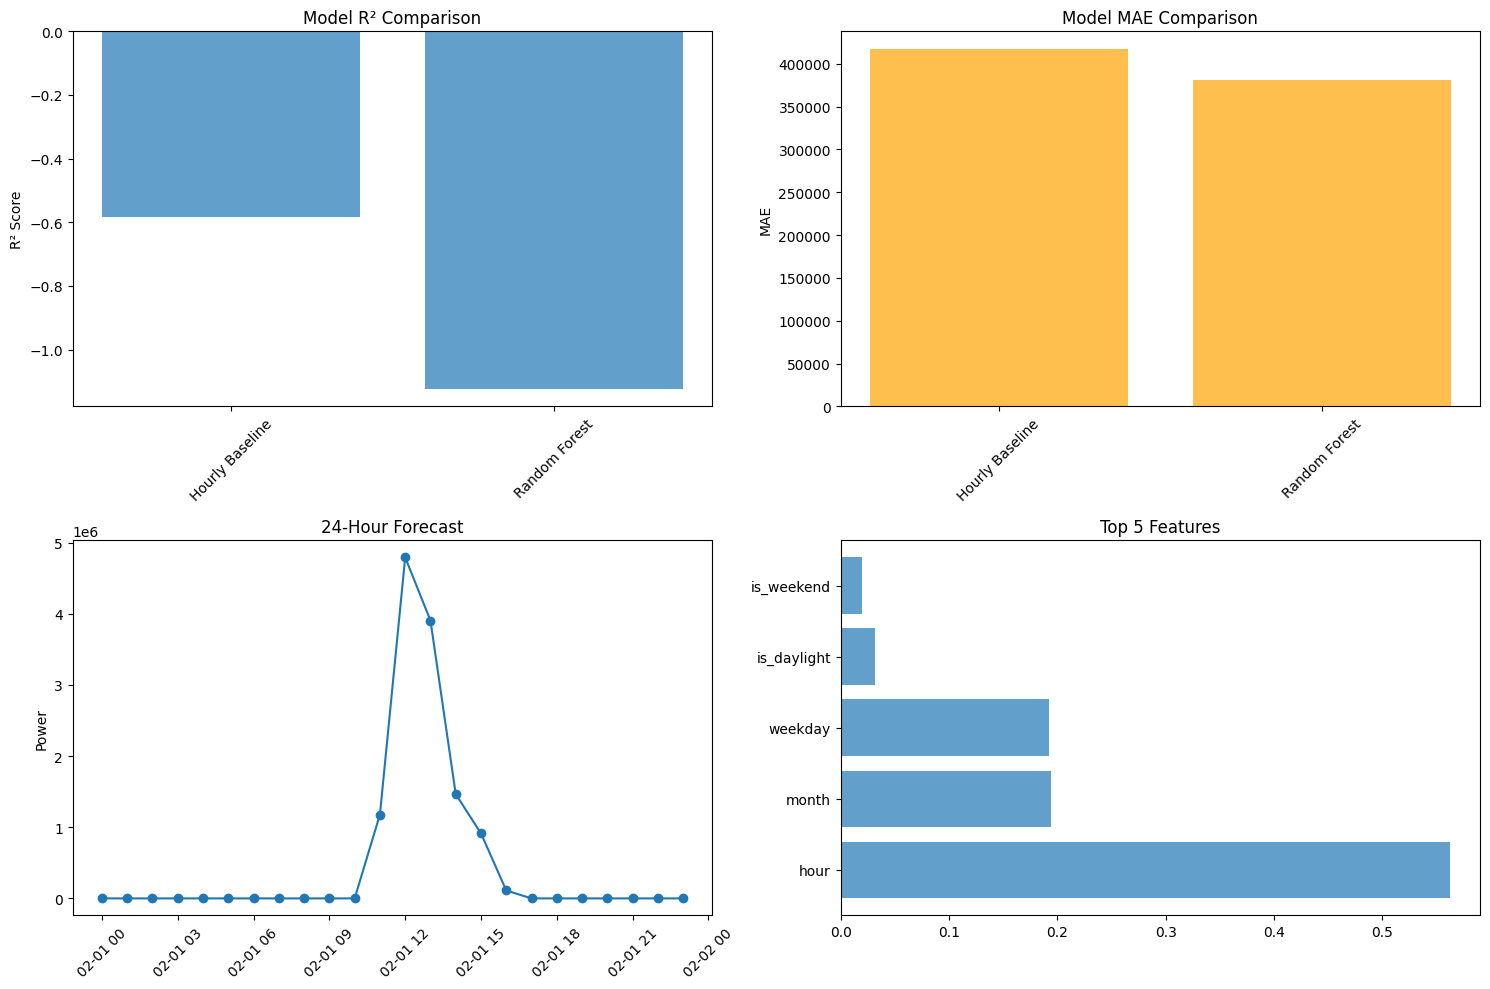

📊 Visualization completed!


In [27]:
# Simple plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Model performance comparison
model_names = [r['name'] for r in results]
r2_scores = [r['R2'] for r in results]
mae_scores = [r['MAE'] for r in results]

axes[0,0].bar(model_names, r2_scores, alpha=0.7)
axes[0,0].set_title('Model R² Comparison')
axes[0,0].set_ylabel('R² Score')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].bar(model_names, mae_scores, alpha=0.7, color='orange')
axes[0,1].set_title('Model MAE Comparison')
axes[0,1].set_ylabel('MAE')
axes[0,1].tick_params(axis='x', rotation=45)

# Forecast visualization
axes[1,0].plot(forecast_results['DateTime'], forecast_results['Predicted_Power'], 'o-')
axes[1,0].set_title('24-Hour Forecast')
axes[1,0].set_ylabel('Power')
axes[1,0].tick_params(axis='x', rotation=45)

# Simple feature importance if RF is available
if 'rf_model' in locals() and rf_model is not None:
    importance = rf_model.feature_importances_
    top_features = sorted(zip(feature_cols, importance), key=lambda x: x[1], reverse=True)[:5]
    feat_names, feat_scores = zip(*top_features)
    
    axes[1,1].barh(feat_names, feat_scores, alpha=0.7)
    axes[1,1].set_title('Top 5 Features')
else:
    axes[1,1].text(0.5, 0.5, 'Feature importance\nnot available', 
                   ha='center', va='center', transform=axes[1,1].transAxes)

plt.tight_layout()
plt.show()

print("📊 Visualization completed!")

In [28]:
# Simple export functionality
if 'forecast_results' in locals():
    print("Saving forecast to CSV...")
    forecast_df = pd.DataFrame(forecast_results)
    forecast_df.to_csv('forecast_results.csv', index=False)
    print("Forecast saved to forecast_results.csv")
    
    # Show stats
    total_power = sum(forecast_results['Predicted_Power'])
    max_power = max(forecast_results['Predicted_Power'])
    avg_power = np.mean(forecast_results['Predicted_Power'])
    
    print(f"Total forecasted production: {total_power:.2f}")
    print(f"Peak production: {max_power:.2f}")
    print(f"Average production: {avg_power:.2f}")
else:
    print("No forecast available to export")

Saving forecast to CSV...
Forecast saved to forecast_results.csv
Total forecasted production: 12368447.18
Peak production: 4794017.48
Average production: 515351.97


In [29]:
# Simple summary 
print("=" * 50)
print("SOLAR POWER ANALYSIS COMPLETED!")
print("=" * 50)

if 'results' in locals():
    print(f"Models trained: {len(results)}")
    best_r2 = max(r['R2'] for r in results)
    print(f"Best R2 score: {best_r2:.3f}")

if 'forecast_results' in locals():
    total_pred = sum(forecast_results['Predicted_Power'])
    print(f"24-hour forecast generated")
    print(f"Total predicted production: {total_pred:.2f}")

print("\nKey Features:")
print("- European number format parsing")
print("- Time-based feature engineering") 
print("- Multiple ML model comparison")
print("- 24-hour power forecasting")
print("- CSV export functionality")
print("\nAnalysis complete!")

SOLAR POWER ANALYSIS COMPLETED!
Models trained: 2
Best R2 score: -0.583
24-hour forecast generated
Total predicted production: 12368447.18

Key Features:
- European number format parsing
- Time-based feature engineering
- Multiple ML model comparison
- 24-hour power forecasting
- CSV export functionality

Analysis complete!


In [30]:
STANDARD_COLS = {
    'date_hour': ['Date - Hour (NMT)', 'Date – Hour (NMT)', 'Date—Hour (NMT)', 'Date Hour (NMT)', 'Date_Hour_NMT', 'Date/Hour', 'Datetime', 'DateTime'],
    'wind_speed': ['Wind Speed','Wind_Speed'],
    'sunshine': ['Sunshine'],
    'air_pressure': ['Air Pressure','Air_Pressure'],
    'radiation': ['Radiation'],
    'air_temperature': ['Air Temperature','Air_Temperature'],
    'relative_air_humidity': ['Relative Air Humidity','Relative_Air_Humidity'],
    'system_production': ['System Production','System_Production','Production','SystemProduction','Actual','y','Y']
}
def coalesce_cols(df, name_key):
    for c in STANDARD_COLS[name_key]:
        if c in df.columns: return c
    return None
def _to_float(series):
    if series.dtype=='O':
        s = series.astype(str).str.replace(r'[^\d,\.\-]+','', regex=True)
        both = s.str.contains(',') & s.str.contains('\.')
        s = np.where(both, s.str.replace(',', ''), s.str.replace(',', '.'))
        series = pd.Series(s)
    return pd.to_numeric(series, errors='coerce')
def parse_datetime_series(s):
    fmts = ['%d.%m.%Y-%H:%M','%Y-%m-%d %H:%M:%S','%Y-%m-%d %H:%M','%m/%d/%Y %H:%M']
    out = []
    for x in s.astype(str):
        val = pd.NaT
        for f in fmts:
            try: val = pd.to_datetime(x, format=f); break
            except Exception: pass
        if pd.isna(val): val = pd.to_datetime(x, errors='coerce')
        out.append(val)
    return pd.Series(out)
def load_excel_sheet(path, sheet):
    df = pd.read_excel(path, sheet_name=sheet)
    df.columns = [str(c).strip() for c in df.columns]
    date_col = coalesce_cols(df, 'date_hour')
    if date_col is None:
        cand = [c for c in df.columns if re.search(r'(date|time|hour)', c, re.I)]
        date_col = cand[0] if cand else None
    if date_col is None: raise ValueError('Kolom tanggal/jam tidak ditemukan.')
    # konversi numerik
    for k in ['wind_speed','sunshine','air_pressure','radiation','air_temperature','relative_air_humidity','system_production']:
        col = coalesce_cols(df, k)
        if col and df[col].dtype=='O': df[col] = _to_float(df[col])
    df['timestamp'] = parse_datetime_series(df[date_col])
    df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)
    # rename standar
    rename_map = {}
    for key in STANDARD_COLS:
        col = coalesce_cols(df, key)
        if col: rename_map[col] = key
    df = df.rename(columns=rename_map)
    # fitur waktu
    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['hour_sin'] = np.sin(2*np.pi*df['hour']/24.0)
    df['hour_cos'] = np.cos(2*np.pi*df['hour']/24.0)
    return df
df_raw = load_excel_sheet(excel_path, sheet_name)
print(df_raw.head())
print('Shape:', df_raw.shape)

NameError: name 'excel_path' is not defined

## 4. Ringkasan & Deskriptif

In [ ]:
desc_cols = [c for c in ['system_production','radiation','sunshine','air_temperature'] if c in df_raw.columns]
display(df_raw[desc_cols].describe().T)
# Distribusi produksi (histogram)
if 'system_production' in df_raw.columns:
    plt.figure(figsize=(6,3))
    plt.hist(df_raw['system_production'].dropna(), bins=30, color='#ffb347')
    plt.title('Distribusi System Production')
    plt.xlabel('Produksi'); plt.ylabel('Frekuensi')
    plt.show()

## 5. Pola Harian / Jam
Melihat rata-rata produksi per jam (0–23).

In [ ]:
if 'system_production' in df_raw.columns:
    hour_avg = df_raw.groupby('hour')['system_production'].mean()
    plt.figure(figsize=(7,3))
    hour_avg.plot(kind='bar', color='#ffa600')
    plt.title('Rata-rata Produksi per Jam')
    plt.xlabel('Jam'); plt.ylabel('Avg Production')
    plt.show()
    display(hour_avg.to_frame('avg_production'))

## 6. Korelasi Sederhana
Digunakan Pearson antar variabel numerik inti.

In [ ]:
num_df = df_raw.select_dtypes(include=['number']).copy()
drop_aux = [c for c in ['hour','dayofweek','month'] if c in num_df.columns]
num_df = num_df.drop(columns=drop_aux, errors='ignore')
if num_df.shape[1] >= 2:
    corr = num_df.corr(numeric_only=True)
    display(corr)
    # Heatmap sederhana manual
    plt.figure(figsize=(5,4))
    plt.imshow(corr, cmap='RdYlBu', vmin=-1, vmax=1)
    plt.colorbar(label='corr')
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title('Heatmap Korelasi')
    plt.tight_layout(); plt.show()
else:
    print('Tidak cukup kolom numerik.')

## 7. Split Data & Helper Agregasi (Jika Mau Harian/Mingguan)

In [ ]:
def aggregate(df, freq='H'):
    if df.empty: return df
    if freq=='D':
        return df.set_index('timestamp').resample('D').mean(numeric_only=True).reset_index()
    if freq=='W':
        return df.set_index('timestamp').resample('W').mean(numeric_only=True).reset_index()
    return df.copy()
df_hourly = df_raw.copy()  # versi jam-an
df_daily = aggregate(df_raw, 'D')
print('Hourly rows:', len(df_hourly), '| Daily rows:', len(df_daily))

## 8. Model Baseline Musiman per Jam
Mengambil rata-rata produksi tiap jam dari 85% awal data sebagai model; sisanya 15% jadi hold-out.

In [ ]:
def seasonal_hourly_baseline(df, horizon=24):
    if df.empty or 'system_production' not in df.columns:
        return pd.DataFrame(columns=['timestamp','yhat']), math.nan, pd.DataFrame(columns=['timestamp','Actual','Prediction'])
    cutoff = int(len(df)*0.85)
    train = df.iloc[:cutoff]; test = df.iloc[cutoff:]
    by_hour = train.groupby(train['timestamp'].dt.hour)['system_production'].mean()
    y_true = test['system_production'].values
    y_pred = test['timestamp'].apply(lambda t: by_hour.get(t.hour, train['system_production'].mean())).values
    holdout = pd.DataFrame({'timestamp': test['timestamp'].values, 'Actual': y_true, 'Prediction': y_pred})
    mae = float(np.nanmean(np.abs(y_true-y_pred))) if len(y_true)>0 else math.nan
    last_ts = df['timestamp'].max()
    future_idx = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=horizon, freq='H')
    fc_vals = [by_hour.get(ts.hour, train['system_production'].mean()) for ts in future_idx]
    fcst = pd.DataFrame({'timestamp': future_idx, 'yhat': fc_vals})
    return fcst, mae, holdout
fcst_base, mae_base, holdout_base = seasonal_hourly_baseline(df_hourly, horizon=24)
print('Baseline MAE:', mae_base)
holdout_base.head()

## 9. Model Regresi Lag + Fitur Waktu
Menggunakan lag (1,2,3,6,12,24) dan jika ada: radiasi (lag), serta sin/cos jam, dayofweek.

In [ ]:
def regression_lag_model(df, horizon=24):
    if df.empty or 'system_production' not in df.columns:
        return pd.DataFrame(columns=['timestamp','yhat']), math.nan, pd.DataFrame(columns=['timestamp','Actual','Prediction'])
    work = df.copy()
    for L in [1,2,3,6,12,24]:
        work[f'lag_{L}'] = work['system_production'].shift(L)
        if 'radiation' in work.columns:
            work[f'rad_lag_{L}'] = work['radiation'].shift(L)
    feat_cols = [c for c in work.columns if c.startswith('lag_') or c.startswith('rad_lag_')]
    for c in ['sunshine','radiation','air_temperature','hour_sin','hour_cos','dayofweek']:
        if c in work.columns: feat_cols.append(c)
    work = work.dropna(subset=feat_cols + ['system_production'])
    if work.empty: return pd.DataFrame(columns=['timestamp','yhat']), math.nan, pd.DataFrame(columns=['timestamp','Actual','Prediction'])
    cutoff = int(len(work)*0.85)
    Xtr, ytr = work.loc[:cutoff-1, feat_cols], work.loc[:cutoff-1, 'system_production']
    Xte, yte = work.loc[cutoff:, feat_cols], work.loc[cutoff:, 'system_production']
    ts_test = work.loc[cutoff:, 'timestamp']
    if SKLEARN_OK:
        model = LinearRegression().fit(Xtr, ytr)
        y_pred = model.predict(Xte) if len(Xte)>0 else np.array([])
    else:
        X_ = np.c_[np.ones(len(Xtr)), Xtr.values]
        beta = np.linalg.lstsq(X_, ytr.values, rcond=None)[0]
        if len(Xte)>0:
            Xte_ = np.c_[np.ones(len(Xte)), Xte.values]
            y_pred = Xte_.dot(beta)
        else: y_pred = np.array([])
    mae = float(np.nanmean(np.abs(yte - y_pred))) if len(y_pred)>0 else math.nan
    holdout = pd.DataFrame({'timestamp': ts_test.values, 'Actual': yte.values, 'Prediction': y_pred})
    # Future recursive
    fc_rows = []; hist = work.copy(); last_ts = df['timestamp'].max()
    for h in range(1, horizon+1):
        next_ts = last_ts + timedelta(hours=h)
        tmp = hist.copy(); tmp.index = pd.DatetimeIndex(tmp['timestamp'])
        def get_lag(col, L):
            try: return tmp.iloc[-L][col]
            except Exception: return np.nan
        feats = {}
        for L in [1,2,3,6,12,24]:
            feats[f'lag_{L}'] = get_lag('system_production', L)
            if 'radiation' in hist.columns:
                feats[f'rad_lag_{L}'] = get_lag('radiation', L)
        for ex in ['sunshine','radiation','air_temperature']:
            if ex in hist.columns: feats[ex] = float(hist[ex].tail(24).mean())
        feats['hour_sin'] = math.sin(2*math.pi*next_ts.hour/24.0)
        feats['hour_cos'] = math.cos(2*math.pi*next_ts.hour/24.0)
        feats['dayofweek'] = next_ts.weekday()
        fv = pd.DataFrame([{k: feats.get(k, np.nan) for k in feat_cols}])
        if SKLEARN_OK:
            yhat = float(model.predict(fv)[0])
        else:
            Xfv = np.c_[np.ones(len(fv)), fv.values]
            yhat = float(Xfv.dot(beta)[0])
        yhat = max(0.0, yhat)
        fc_rows.append({'timestamp': next_ts, 'yhat': yhat})
        add_row = {'timestamp': next_ts, 'system_production': yhat}
        for ex in ['sunshine','radiation','air_temperature']:
            if ex in hist.columns: add_row[ex] = feats.get(ex, np.nan)
        hist = pd.concat([hist, pd.DataFrame([add_row])], ignore_index=True)
    fcst = pd.DataFrame(fc_rows)
    return fcst, mae, holdout
fcst_reg, mae_reg, holdout_reg = regression_lag_model(df_hourly, horizon=24)
print('Regresi MAE:', mae_reg)
holdout_reg.head()

## 10. Evaluasi Hold-Out (Baseline vs Regresi)

In [ ]:
def mape(df):
    if df.empty: return math.nan
    err = np.abs(df['Actual'] - df['Prediction'])
    with np.errstate(divide='ignore', invalid='ignore'):
        return float(np.nanmean(err / np.where(df['Actual']==0, np.nan, df['Actual']))*100.0)
mape_base = mape(holdout_base); mape_reg = mape(holdout_reg)
print(f'Baseline -> MAE: {mae_base:.2f} | MAPE: {mape_base:.2f}%')
print(f'Regresi  -> MAE: {mae_reg:.2f} | MAPE: {mape_reg:.2f}%')
# Plot Actual vs Prediction (gunakan model regresi jika tersedia)
if not holdout_reg.empty:
    plt.figure(figsize=(8,3))
    plt.plot(holdout_reg['timestamp'], holdout_reg['Actual'], label='Actual', lw=1.5)
    plt.plot(holdout_reg['timestamp'], holdout_reg['Prediction'], label='Prediction', lw=1.2)
    plt.title('Hold-out Actual vs Prediction (Regresi)')
    plt.legend(); plt.tight_layout(); plt.show()
elif not holdout_base.empty:
    plt.figure(figsize=(8,3))
    plt.plot(holdout_base['timestamp'], holdout_base['Actual'], label='Actual', lw=1.5)
    plt.plot(holdout_base['timestamp'], holdout_base['Prediction'], label='Prediction', lw=1.2)
    plt.title('Hold-out Actual vs Prediction (Baseline)')
    plt.legend(); plt.tight_layout(); plt.show()

## 11. Forecast ke Depan
Menampilkan histori singkat + hasil forecast (model regresi diprioritaskan, fallback baseline).

In [ ]:
hist_tail = df_hourly.tail(24*7)[['timestamp','system_production']] if 'system_production' in df_hourly.columns else df_hourly.tail(24*7)[['timestamp']]
model_fcst = fcst_reg if not fcst_reg.empty else fcst_base
plt.figure(figsize=(9,3))
if 'system_production' in hist_tail.columns:
    plt.plot(hist_tail['timestamp'], hist_tail['system_production'], label='History (last 7d)')
plt.plot(model_fcst['timestamp'], model_fcst['yhat'], label='Forecast', color='tomato')
plt.title('History + Forecast ke Depan')
plt.legend(); plt.tight_layout(); plt.show()
model_fcst.head()

## 12. Export Hasil
Simpan ke CSV (forecast) & Excel (opsional).

In [ ]:
out_fcst = model_fcst.rename(columns={'yhat':'Forecast'})
csv_name = 'forecast_output.csv'
out_fcst.to_csv(csv_name, index=False)
print('Tersimpan:', csv_name)
excel_name = 'forecast_output.xlsx'
with pd.ExcelWriter(excel_name, engine='xlsxwriter') as w:
    out_fcst.to_excel(w, sheet_name='Forecast', index=False)
print('Tersimpan:', excel_name)

## 13. Next Steps (Ide Pengembangan)
1. Tambahkan model Prophet / XGBoost / LSTM untuk perbandingan.
2. Hyperparameter tuning (window lag lebih banyak, rolling stats).
3. Evaluasi musiman harian vs mingguan (tambahkan dummy weekend).
4. Deploy ulang ke dashboard Streamlit dengan opsi pilih model.